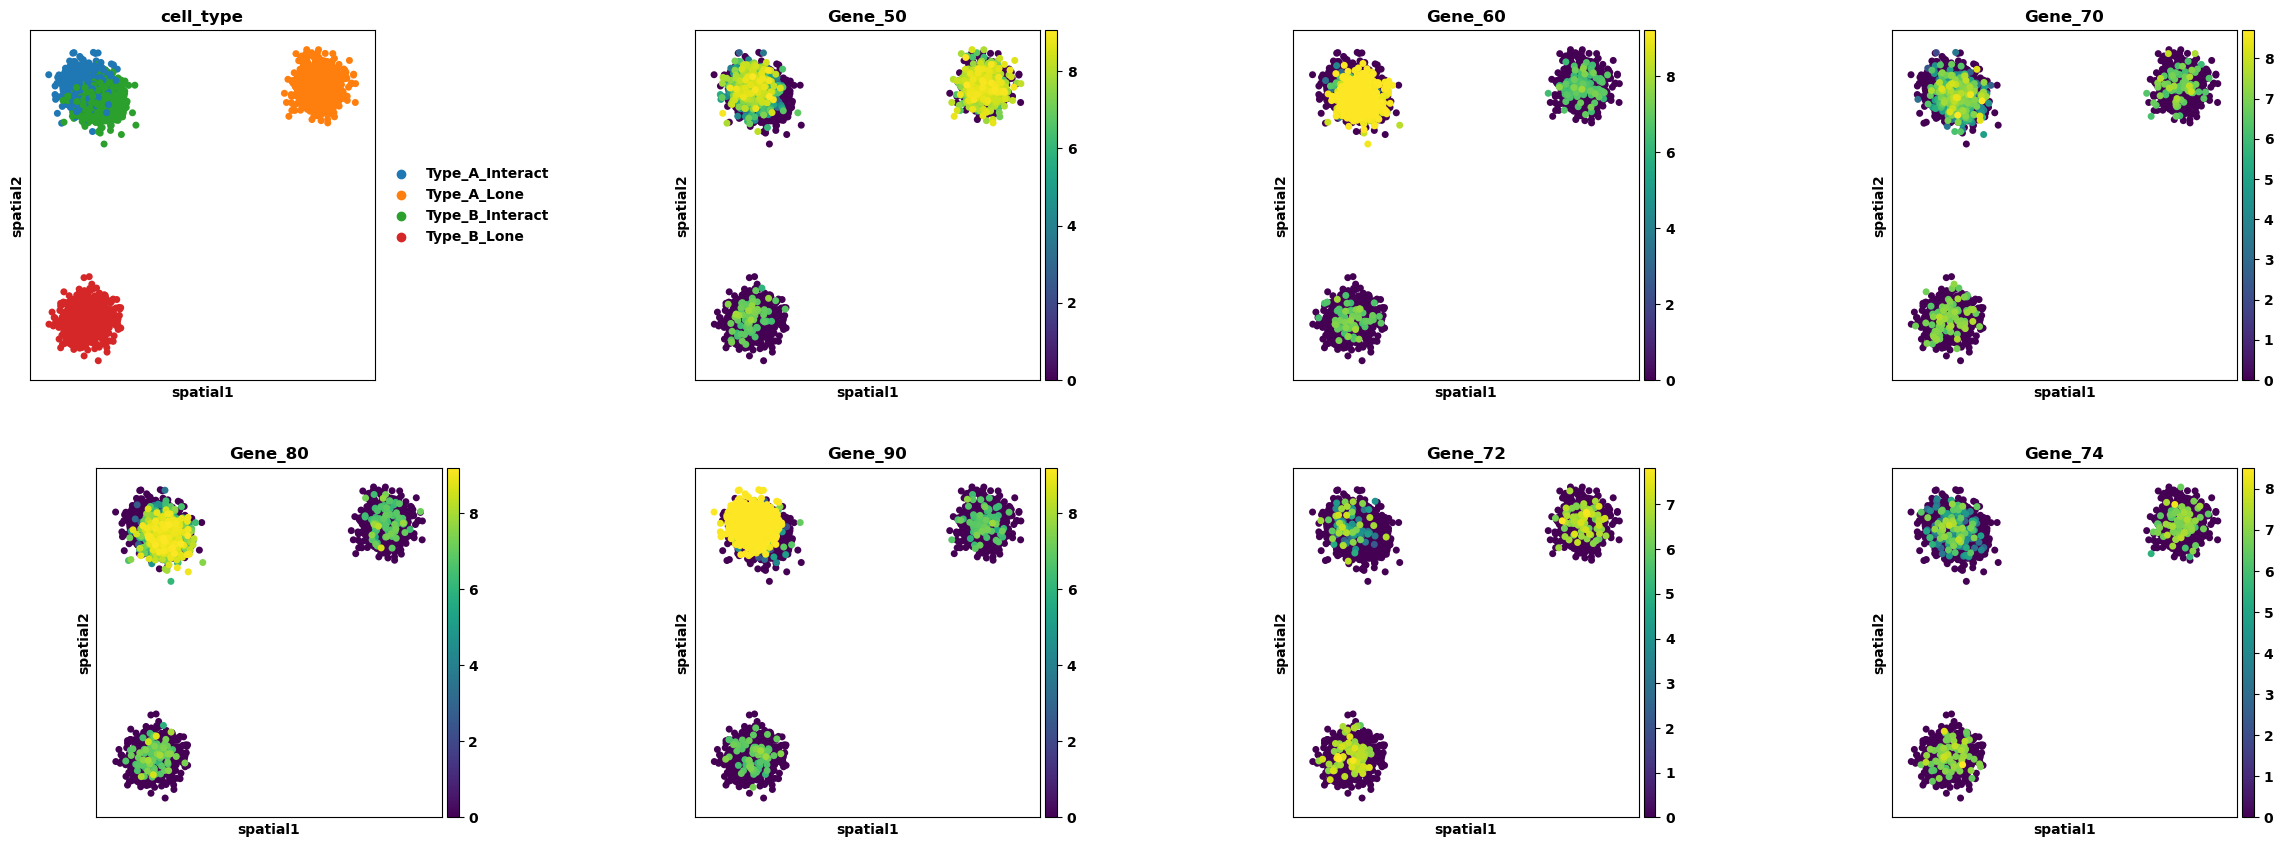

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.spatial.distance import cdist
from sklearn.datasets import make_blobs

def simulate_complex_benchmarking_tissue(
    n_cells=4000, 
    n_genes=120, 
    lr_forward={50: 60},     
    lr_retro={80: 90},       
    grn_logic={70: {71: 1.5, 72: -1.5, 80: 2.0}}, 
    receptor_to_grn={60: 70},
    sparsity_factor=0.4
):
    # --- 1. SETUP SPATIAL SCENARIOS ---
    centroids = [[10, 10], [12, 12], [50, 10], [10, 50]]
    coords, labels = make_blobs(n_samples=n_cells, centers=centroids, cluster_std=2.0, random_state=42)
    
    role_map = {0: 'Type_A_Interact', 1: 'Type_B_Interact', 2: 'Type_A_Lone', 3: 'Type_B_Lone'}
    cell_types = np.array([role_map[l] for l in labels])

    # --- 2. INITIALIZATION ---
    mu_0 = -2.0
    latent_X = np.random.normal(mu_0, 0.5, (n_cells, n_genes))
    
    # Adjacency Matrix defines ALL internal relationships
    A_mat = np.zeros((n_genes, n_genes))
    if grn_logic:
        for source, targets in grn_logic.items():
            for target, weight in targets.items():
                A_mat[target, source] = weight

    # --- 3. SPATIAL WEIGHTING ---
    dist_mat = cdist(coords, coords)
    sigma = 4.0
    W = np.exp(-(dist_mat**2) / (2 * sigma**2))
    np.fill_diagonal(W, 0)

    # --- 4. SIMULATION ENGINE ---
    is_a = np.char.startswith(cell_types, 'Type_A')
    is_b = np.char.startswith(cell_types, 'Type_B')

    # STEP A: All Senders (A) produce Forward Ligand (50)
    # This is the "Environmental Input"
    for l_idx in lr_forward.keys():
        latent_X[is_a, l_idx] += 3.5

    # STEP B: Spatial Interaction Pass 1 (A -> B)
    for i in range(n_cells):
        if 'Type_B' in cell_types[i]:
            for l_idx, r_idx in lr_forward.items():
                signal = np.sum(W[i, is_a] * np.exp(latent_X[is_a, l_idx]))
                latent_X[i, r_idx] += np.log1p(signal * 2.0)
                
                # Receptor 60 triggers Master 70
                if r_idx in receptor_to_grn and latent_X[i, r_idx] > 0.5:
                    ms = receptor_to_grn[r_idx]
                    latent_X[i, ms] += 2.5 

    # STEP C: Intracellular Propagation (GRN)
    # This now handles 71, 72, and 80 based on A_mat
    for i in range(n_cells):
        current_snapshot = latent_X[i, :].copy()
        for target_gene in range(n_genes):
            sources = np.where(A_mat[target_gene, :] != 0)[0]
            for source_gene in sources:
                weight = A_mat[target_gene, source_gene]
                if current_snapshot[source_gene] > -1.0: 
                    delta = (current_snapshot[source_gene] - mu_0)
                    latent_X[i, target_gene] += weight * delta

    # STEP D: Spatial Interaction Pass 2 (B -> A Feedback)
    for i in range(n_cells):
        if 'Type_A' in cell_types[i]:
            for l_idx, r_idx in lr_retro.items():
                signal = np.sum(W[i, is_b] * np.exp(latent_X[is_b, l_idx]))
                latent_X[i, r_idx] += np.log1p(signal * 2.5)

    # --- 5. STABILIZATION & SAMPLING ---
    latent_X = np.clip(latent_X, -10, 6)
    mu = np.exp(latent_X)
    phi = 0.8
    counts = np.random.negative_binomial(1/phi, (1/phi)/(1/phi + mu))
    dropout_mask = np.random.binomial(1, 1 - sparsity_factor, size=counts.shape)
    counts = counts * dropout_mask

    # --- 6. PACKAGING ---
    adata = ad.AnnData(X=counts.astype(np.float32))
    adata.obs['cell_type'] = cell_types
    adata.obsm['spatial'] = coords
    adata.var_names = [f"Gene_{i}" for i in range(n_genes)]
    
    return adata

# --- EXECUTION ---
adata = simulate_complex_benchmarking_tissue(    
    n_cells=4000, 
    n_genes=120, 
    lr_forward={50: 60},
    receptor_to_grn={60: 70},
    grn_logic={
        # Module 1: Spatial/Reactive (Triggered by Receptor 60)
        70: {71: 1.5, 72: -1.5, 80: 2.0}, 
        # Module 2: Autonomous/Constitutive (Happens "despite anything")
        73: {74: 1.5, 75: 2.0, 76: -1.5}  
    },
    lr_retro={80: 90},
    sparsity_factor=0.4
)

adata.layers['counts'] = adata.X.copy()
# Standard Normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# --- VISUALIZATION ---
sc.pl.spatial(
    adata, 
    color=[
        'cell_type', # Context
        'Gene_50',   # Stage 1: Forward Ligand (A)
        'Gene_60',   # Stage 2: Forward Sensing (B)
        'Gene_70',   # Stage 3: Master Switch (B)
        'Gene_80',   # Stage 4: Feedback Ligand (B)
        'Gene_90',   # Stage 5: Feedback Sensing (A) - The "Quantum" Signal
        'Gene_72',   # Logic check: Repression by 70
        'Gene_74'    # Specificity check: Autonomous GRN (Non-spatial)
    ], 
    spot_size=1.2, 
    ncols=4,
    cmap='viridis'
)

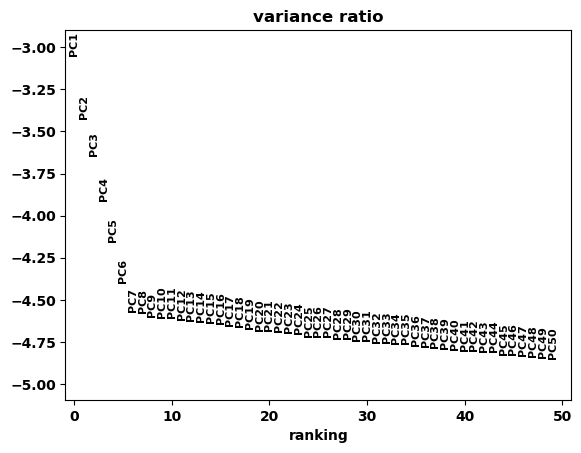

In [98]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [99]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [100]:
adata

AnnData object with n_obs × n_vars = 4000 × 120
    obs: 'cell_type'
    uns: 'log1p', 'cell_type_colors', 'pca', 'neighbors', 'umap'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

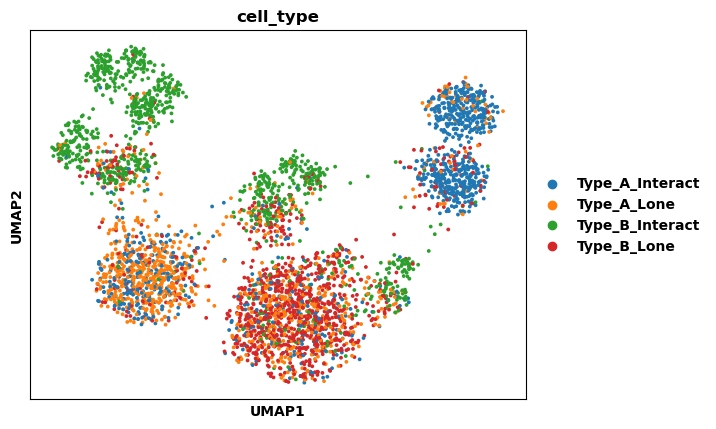

In [101]:
sc.pl.umap(
    adata,
    color="cell_type",
)

In [103]:
import scipy.sparse as sp
adata.X = sp.csr_matrix(adata.X)
adata.layers['counts'] = sp.csr_matrix(adata.layers['counts'])
adata.write_h5ad('sim_cells_datasets_co_mo_simulated_classical.h5ad')
#adata_merged.write_h5ad('sim_merged_datasets_co_mo_quantum_device.h5ad')